In [42]:
!pip install -q transformers datasets accelerate evaluate scikit-learn pandas

In [43]:
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [44]:
import pandas as pd

file_path = '/kaggle/input/datasets/quannvh/datasemantic-clone/dataset (2)/dataset/data.jsonl'
df = pd.read_json(file_path, lines=True)
display(df.head())

,func,idx
0,public static void main(String[] args) {\n...,10000832
1,public synchronized String getSerialNumber...,10005623
2,public Object run() {\n ...,10005624
3,public String post() {\n if (conten...,10005674
4,@Override\n public void onCreate(Bundle...,10005879


In [45]:
id_to_code = {}
with open("/kaggle/input/datasets/quannvh/datasemantic-clone/dataset (2)/dataset/data.jsonl","r",encoding = "utf-8") as f:
  for line in f:
    line = line.strip()
    if not line:
      continue
    js = json.loads(line)
    id_to_code[js["idx"]] = js["func"]

In [46]:
print("So luong function trong data.jsonl:", len(id_to_code))
sample_keys = list(id_to_code.keys())[:3]

for k in sample_keys:
    print("ID:", k)
    print(id_to_code[k][:300])   # in 300 ký tự đầu cho đỡ dài
    print("=" * 80)

So luong function trong data.jsonl: 9126
ID: 10000832
    public static void main(String[] args) {
        LogFrame.getInstance();
        for (int i = 0; i < args.length; i++) {
            String arg = args[i];
            if (arg.trim().startsWith(DEBUG_PARAMETER_NAME + "=")) {
                properties.put(DEBUG_PARAMETER_NAME, arg.trim().substrin
ID: 10005623
    public synchronized String getSerialNumber() {
        if (serialNum != null) return serialNum;
        final StringBuffer buf = new StringBuffer();
        Iterator it = classpath.iterator();
        while (it.hasNext()) {
            ClassPathEntry entry = (ClassPathEntry) it.next();
         
ID: 10005624
            public Object run() {
                try {
                    MessageDigest digest = MessageDigest.getInstance("SHA");
                    digest.update(buf.toString().getBytes());
                    byte[] data = digest.digest();
                    serialNum = new BASE64Encoder().en


In [47]:
train_file = "/kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/train_50000.txt"
test_file = "/kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/test_50000.txt"
valid_file = "/kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/valid_50000.txt"

In [48]:
def read_pairs(pair_file, id_to_code):
    samples = []
    skipped_missing_code = 0
    skipped_bad_format = 0
    skipped_bad_label = 0

    with open(pair_file) as f:
        for line in f:
            line = line.strip()
            id1, id2, label = line.split('\t')
            if id1 not in id_to_code or id2 not in id_to_code:
                continue
            label = int(label)
            if label in [0, 1, 2, 3]:
                samples.append({
                "id1": id1,
                "id2": id2,
                "code1": id_to_code[id1],
                "code2": id_to_code[id2],
                "label": label
                })
    print(f"\nDoc file: {pair_file}")
    print("So sample hop le:", len(samples))
    return samples

In [49]:
train_samples = read_pairs(train_file, id_to_code)
valid_samples = read_pairs(valid_file, id_to_code)
test_samples  = read_pairs(test_file, id_to_code)


Doc file: /kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/train_50000.txt
So sample hop le: 19628

Doc file: /kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/valid_50000.txt
So sample hop le: 6541

Doc file: /kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/test_50000.txt
So sample hop le: 6494


In [50]:
train_df = pd.DataFrame(train_samples)
valid_df = pd.DataFrame(valid_samples)
test_df  = pd.DataFrame(test_samples)

print(train_df.head())
print(train_df.shape, valid_df.shape, test_df.shape)

        id1       id2                                              code1  \
0   8539546  13106834      private static void unpackEntry(File desti...   
1    364438    441377      public void convert(File src, File dest) t...   
2   9597889  21319238      private void copy(File source, File dest) ...   
3  18731109  23273706      public static boolean encodeFileToFile(Str...   
4  17147420  21933390      public final String latestVersion() {\n   ...   

                                               code2  label  
0      public void copyFilesIntoProject(HashMap<S...      3  
1      public void convert(File src, File dest) t...      0  
2      FileCacheInputStreamFountain(FileCacheInpu...      3  
3      public String[][] getProjectTreeData() {\n...      3  
4      public static List<String> getServers() th...      2  
(19628, 5) (6541, 5) (6494, 5)


In [51]:
print("Train label distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValid label distribution:")
print(valid_df["label"].value_counts().sort_index())

print("\nTest label distribution:")
print(test_df["label"].value_counts().sort_index())

Train label distribution:
label
0    2534
1    6693
2    5251
3    5150
Name: count, dtype: int64

Valid label distribution:
label
0     856
1    2226
2    1728
3    1731
Name: count, dtype: int64

Test label distribution:
label
0     812
1    2234
2    1745
3    1703
Name: count, dtype: int64


In [52]:
train_ds = Dataset.from_pandas(train_df[["code1", "code2", "label"]], preserve_index=False)
valid_ds = Dataset.from_pandas(valid_df[["code1", "code2", "label"]], preserve_index=False)
test_ds  = Dataset.from_pandas(test_df[["code1", "code2", "label"]], preserve_index=False)

print(train_ds)
print(valid_ds)
print(test_ds)

Dataset({
    features: ['code1', 'code2', 'label'],
    num_rows: 19628
})
Dataset({
    features: ['code1', 'code2', 'label'],
    num_rows: 6541
})
Dataset({
    features: ['code1', 'code2', 'label'],
    num_rows: 6494
})


In [53]:
# Load tokenizer và model CodeBERT
model_name = "microsoft/codebert-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Để tiếp tục huấn luyện từ một checkpoint đã lưu, bạn cần truyền đường dẫn đến checkpoint đó vào phương thức `trainer.train()` thông qua đối số `resume_from_checkpoint`. Thông thường, `output_dir` của `TrainingArguments` sẽ chứa các thư mục checkpoint, ví dụ `/content/codebert_4class_output/checkpoint-XXXXX`.

In [54]:
# Ví dụ về cách tiếp tục huấn luyện từ một checkpoint cụ thể
# Thay thế 'path/to/your/checkpoint' bằng đường dẫn thực tế của checkpoint bạn muốn tiếp tục

# trainer.train(resume_from_checkpoint='/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535')

# Hoặc, để tiếp tục từ checkpoint cuối cùng (nếu có nhiều hơn một)
# trainer.train(resume_from_checkpoint=True)

print("Để tiếp tục huấn luyện, bạn sẽ cần chạy lại ô tạo Trainer và sau đó gọi `trainer.train(resume_from_checkpoint=path_to_checkpoint)`")

Để tiếp tục huấn luyện, bạn sẽ cần chạy lại ô tạo Trainer và sau đó gọi `trainer.train(resume_from_checkpoint=path_to_checkpoint)`


In [55]:
max_length = 512

In [56]:
def tokenize_function(examples):
    return tokenizer(
        examples["code1"],
        examples["code2"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

train_tokenized = train_ds.map(tokenize_function, batched=True)
valid_tokenized = valid_ds.map(tokenize_function, batched=True)
test_tokenized  = test_ds.map(tokenize_function, batched=True)

Map:   0%|          | 0/19628 [00:00<?, ? examples/s]

Map:   0%|          | 0/6541 [00:00<?, ? examples/s]

Map:   0%|          | 0/6494 [00:00<?, ? examples/s]

In [57]:
columns = ["input_ids", "attention_mask", "label"]

if "token_type_ids" in train_tokenized.column_names:
    columns.append("token_type_ids")

train_tokenized.set_format(type="torch", columns=columns)
valid_tokenized.set_format(type="torch", columns=columns)
test_tokenized.set_format(type="torch", columns=columns)

print(train_tokenized[0])

{'label': tensor(3), 'input_ids': tensor([    0,  1437,  1437,  1437,   940, 25156, 13842,   542, 12486, 46640,
         1640,  9966,  6381,  9966,     6, 38277, 48214, 36757,   992,   179,
            6, 38277, 46640,  3555,    43,  6989, 47617, 25522, 50118,  1437,
         1437,  1437,  1437,  1437,  1437,  1437,   114, 48209, 12595,     4,
          354, 49226, 49338, 25522, 50118,  1437,  1437,  1437,  1437,  1437,
         1437,  1437,  1437,  1437,  1437,  1437,  1045,   597,   279,   268,
         1640, 31549,  8111,  9966,     4,  6460, 46102,  9966, 49291, 50118,
         1437,  1437,  1437,  1437,  1437,  1437,  1437,  1437,  1437,  1437,
         1437,  8655, 48293, 36757,   856,   354,  5457,    92,  8655, 48293,
        36757,  1640, 31549,  8111,  9966,  4397, 50118,  1437,  1437,  1437,
         1437,  1437,  1437,  1437,  1437,  1437,  1437,  1437,   860, 25522,
        50118,  1437,  1437,  1437,  1437,  1437,  1437,  1437,  1437,  1437,
         1437,  1437,  1437,  

In [58]:
# Hàm Metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    f1_weighted = f1_score(labels, preds, average="weighted", zero_division=0)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

In [59]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/codebert_4class_output", # Changed to save to Google Drive

    eval_strategy="steps", # Changed to steps to match save_strategy
    eval_steps=24535, # Evaluate every 5 epochs (19628 samples / 4 batch_size * 5 epochs)
    save_strategy="steps", # Changed to steps
    save_steps=24535, # Save every 5 epochs (19628 samples / 4 batch_size * 5 epochs)
    logging_strategy="steps",
    logging_steps=100,

    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    fp16=True,
    report_to="none"
)

In [60]:
import time
import torch
from transformers import TrainerCallback

class TimerCallback(TrainerCallback):
    def on_epoch_begin(self, args, state, control, **kwargs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        self.epoch_start = time.time()

    def on_epoch_end(self, args, state, control, **kwargs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        epoch_time = time.time() - self.epoch_start

        print(f"\nEpoch {int(state.epoch)} time: {epoch_time:.2f} seconds")
        print(f"Epoch {int(state.epoch)} time: {epoch_time / 60:.2f} minutes")

In [61]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=valid_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[TimerCallback()]
)

In [62]:
# trainer.train(resume_from_checkpoint='/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535')
# trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss



Epoch 1 time: 1259.49 seconds
Epoch 1 time: 20.99 minutes

Epoch 2 time: 1258.38 seconds
Epoch 2 time: 20.97 minutes


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch 3 time: 1261.53 seconds
Epoch 3 time: 21.03 minutes


TrainOutput(global_step=7362, training_loss=0.6313647462181086, metrics={'train_runtime': 3779.4085, 'train_samples_per_second': 15.58, 'train_steps_per_second': 1.948, 'total_flos': 1.5493309595172864e+16, 'train_loss': 0.6313647462181086, 'epoch': 3.0})

In [63]:
print("Hello")

Hello


In [1]:
# load model to evaluate
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments 
path = "/kaggle/input/datasets/quannvh/checkpoint-codebert-15epochs/codebert_4class_output/checkpoint-24535"
model = AutoModelForSequenceClassification.from_pretrained(path)
tokenizer = AutoTokenizer.from_pretrained(path)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [65]:
new_train_args = training_args
new_train_args.output_dir = "/kaggle/working/evaluate"
train = Trainer(
    model=model,
    args=new_train_args,
    train_dataset=train_tokenized,
    eval_dataset=valid_tokenized,
    compute_metrics=compute_metrics
)

In [66]:
trainer = train
# Assess in Validation
valid_results = trainer.evaluate(valid_tokenized)
print(valid_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.4915447235107422, 'eval_accuracy': 0.9026142791622076, 'eval_precision_macro': 0.9075432147584168, 'eval_recall_macro': 0.9080137571911978, 'eval_f1_macro': 0.9077426476887253, 'eval_f1_weighted': 0.9025747101945728, 'eval_runtime': 136.2853, 'eval_samples_per_second': 47.995, 'eval_steps_per_second': 6.002}


In [67]:
print("==========")
if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.time()
test_results = trainer.evaluate(test_tokenized)
if torch.cuda.is_available():
    torch.cuda.synchronize()

end = time.time()

test_time = end - start

print(f"Test time: {test_time:.2f} seconds")
print(f"Test time: {test_time/60:.2f} minutes")
print(test_results)

num_samples = len(test_tokenized)

print(f"Average latency/sample: {test_time / num_samples:.6f} sec")
print(f"Throughput: {num_samples / test_time:.2f} samples/sec")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Test time: 134.54 seconds
Test time: 2.24 minutes
{'eval_loss': 1.4646015167236328, 'eval_accuracy': 0.9040652910378811, 'eval_precision_macro': 0.9100109009276538, 'eval_recall_macro': 0.909798064093871, 'eval_f1_macro': 0.9096542637884605, 'eval_f1_weighted': 0.9039730199868923, 'eval_runtime': 134.5326, 'eval_samples_per_second': 48.271, 'eval_steps_per_second': 6.036}
Average latency/sample: 0.020717 sec
Throughput: 48.27 samples/sec


In [ ]:
print(num_samples)

In [68]:
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(test_tokenized)
preds = np.argmax(pred_output.predictions, axis=-1)
labels = pred_output.label_ids

print(classification_report(labels, preds, digits=4))
print("Confusion matrix:")
print(confusion_matrix(labels, preds))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       812
           1     0.9982    1.0000    0.9991      2234
           2     0.8384    0.7966    0.8169      1745
           3     0.8035    0.8426    0.8226      1703

    accuracy                         0.9041      6494
   macro avg     0.9100    0.9098    0.9097      6494
weighted avg     0.9044    0.9041    0.9040      6494

Confusion matrix:
[[ 812    0    0    0]
 [   0 2234    0    0]
 [   0    4 1390  351]
 [   0    0  268 1435]]


In [69]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

# normalize theo hàng
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

print(cm_norm)

[[100.           0.           0.           0.        ]
 [  0.         100.           0.           0.        ]
 [  0.           0.22922636  79.65616046  20.11461318]
 [  0.           0.          15.73693482  84.26306518]]


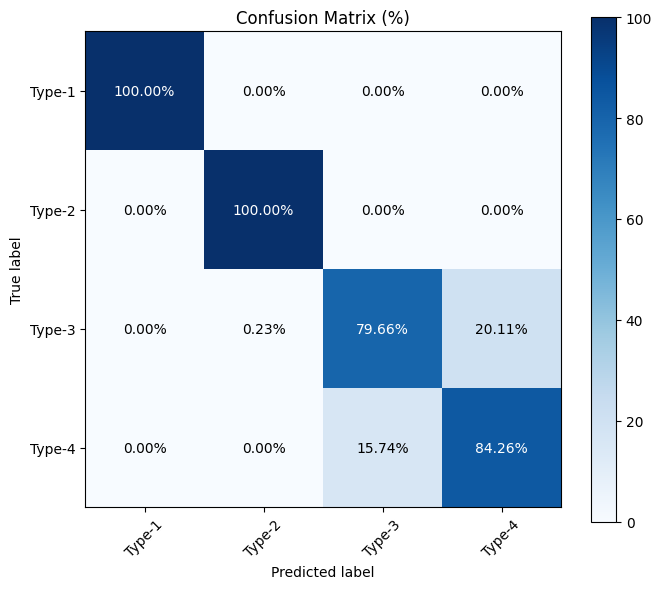

In [70]:
plt.figure(figsize=(7, 6))
plt.imshow(cm_norm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix (%)")
plt.colorbar()

class_names = ["Type-1", "Type-2", "Type-3", "Type-4"]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        color = "white" if i == j else "black"
        plt.text(j, i, f"{cm_norm[i, j]:.2f}%",
                 ha="center", va="center", color=color)

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

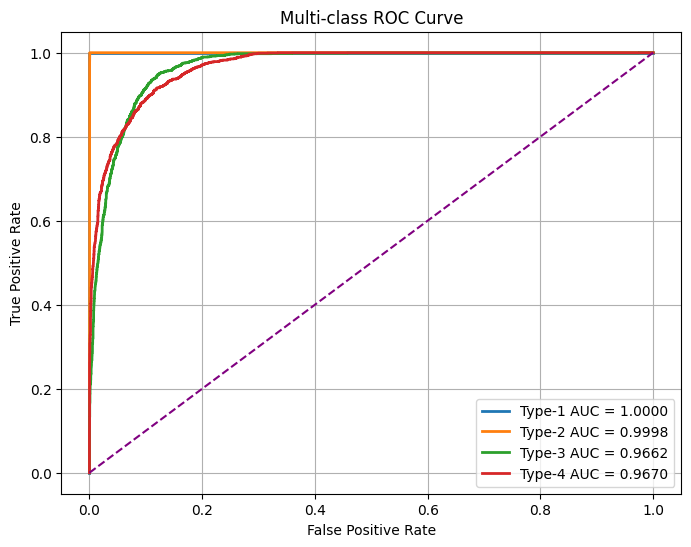

In [1]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# logits
y_score = pred_output.predictions

# chuyển sang xác suất
exp_scores = np.exp(y_score)
y_prob = exp_scores / exp_scores.sum(axis=1, keepdims=True)

# one-hot label
y_true = label_binarize(labels, classes=[0,1,2,3])

class_names = ["Type-1", "Type-2", "Type-3", "Type-4"]

plt.figure(figsize=(8,6))

for i in range(4):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{class_names[i]} AUC = {roc_auc:.4f}"
    )

plt.plot([0,1],[0,1],'--',color='purple')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
from transformers import AutoModel
import torch

encoder = AutoModel.from_pretrained(path)

encoder.to("cuda")
encoder.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: /kaggle/input/datasets/quannvh/checkpoint-codebert-15epochs/codebert_4class_output/checkpoint-24535
Key                        | Status     | 
---------------------------+------------+-
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

In [2]:
path = "/kaggle/input/datasets/quannvh/checkpoint-codebert-15epochs/codebert_4class_output/checkpoint-24535"

In [3]:
import numpy as np
from torch.utils.data import DataLoader

test_loader = trainer.get_test_dataloader(test_tokenized)

embeddings = []
labels_tsne = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].cuda()
        attention_mask = batch["attention_mask"].cuda()

        outputs = encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]

        embeddings.append(
            cls_embedding.cpu().numpy()
        )

        labels_tsne.append(
            batch["labels"].cpu().numpy()
        )

embeddings = np.concatenate(embeddings)
labels_tsne = np.concatenate(labels_tsne)

print(embeddings.shape)

(6494, 768)


In [4]:
emb_subset = embeddings
label_subset = labels_tsne

In [12]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

emb_2d = tsne.fit_transform(emb_subset)

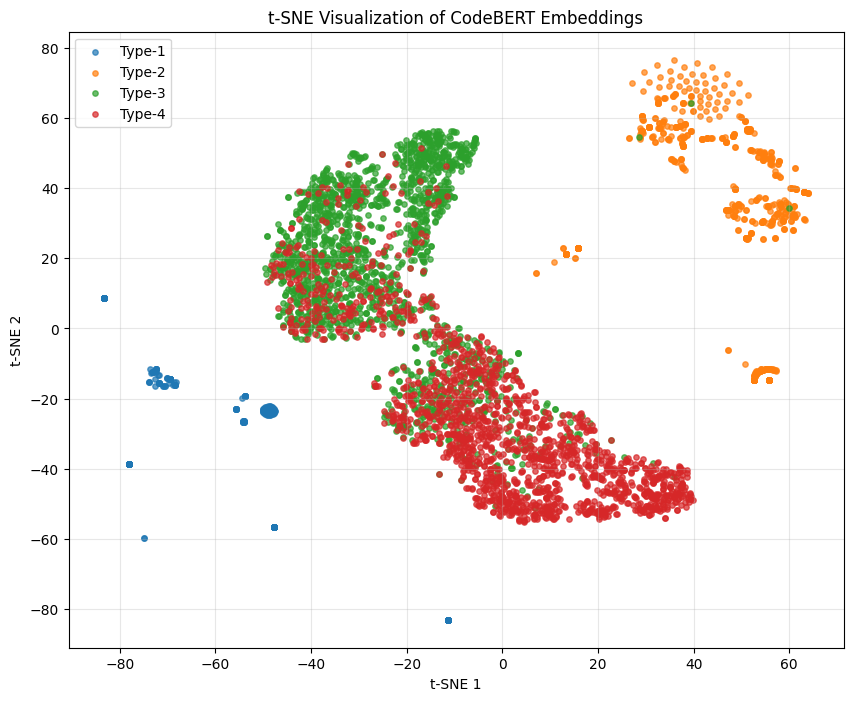

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

colors = ["blue", "orange", "green", "red"]
names = ["Type-1", "Type-2", "Type-3", "Type-4"]

for cls in range(4):

    mask = label_subset == cls

    plt.scatter(
        emb_2d[mask,0],
        emb_2d[mask,1],
        s=15,
        alpha=0.7,
        label=names[cls]
    )

plt.title("t-SNE Visualization of CodeBERT Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Number of samples for t-SNE: 3000


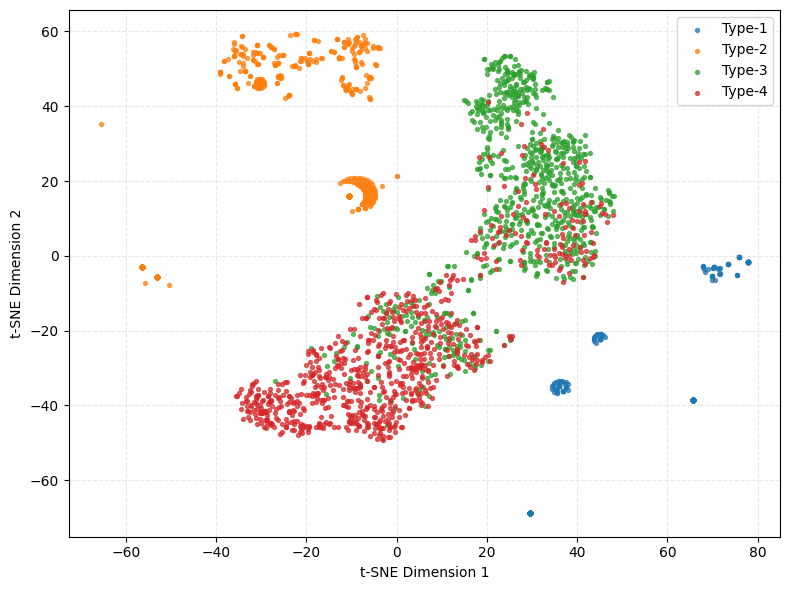

In [14]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Số mẫu dùng để vẽ t-SNE
N_TSNE = 3000
RANDOM_STATE = 42

# Nếu tập test lớn hơn 5000 thì lấy mẫu stratified theo nhãn
if len(labels_tsne) > N_TSNE:
    idx = np.arange(len(labels_tsne))

    _, sample_idx = train_test_split(
        idx,
        test_size=N_TSNE,
        random_state=RANDOM_STATE,
        stratify=labels_tsne
    )

    embeddings_vis = embeddings[sample_idx]
    labels_vis = labels_tsne[sample_idx]
else:
    embeddings_vis = embeddings
    labels_vis = labels_tsne

print("Number of samples for t-SNE:", embeddings_vis.shape[0])

# Chuẩn hóa embedding trước khi t-SNE
embeddings_vis = StandardScaler().fit_transform(embeddings_vis)

# Chạy t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

embeddings_2d = tsne.fit_transform(embeddings_vis)

# Vẽ hình
plt.figure(figsize=(8, 6))

for label in np.unique(labels_vis):
    idx = labels_vis == label
    plt.scatter(
        embeddings_2d[idx, 0],
        embeddings_2d[idx, 1],
        s=8,
        alpha=0.7,
        label=f"Type-{label + 1}"
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()